# Calibration Cox

**This notebook assesses calibration performance of the cox model and recalibrates predictions using isotonic regression.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.isotonic import IsotonicRegression
from sksurv.metrics import brier_score

from utils.calibration import calculate_calibration_curve, calibrate_survival_predictions

## Import Data

In [2]:
survival_predictions_df = pd.read_csv('../outputs/cox_survival_predictions.csv')

In [3]:
survival_predictions_df = survival_predictions_df[['PatientID', 'risk_score', 'psurv_180']]

In [4]:
survival_predictions_df.shape

(9357, 3)

In [5]:
dtype_map = pd.read_csv('../outputs/pembro_carbo_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
pembro_carbo_df = pd.read_csv('../outputs/pembro_carbo_features_df.csv', dtype = dtype_map)

In [6]:
pembro_carbo_df.shape

(3706, 162)

In [7]:
df = pd.merge(pembro_carbo_df, survival_predictions_df, on = 'PatientID', how = 'left')

In [8]:
df.shape

(3706, 164)

In [9]:
df = df.query('adv_diagnosis_year <= 2021')

In [10]:
df.shape

(3138, 164)

## Raw Calibration Assessment

In [11]:
cal_df = calculate_calibration_curve(df, 'psurv_180', 180)

In [12]:
cal_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.0009056, 0.463]",0.314964,0.262281,314,0.210183,0.309906
1,"(0.463, 0.585]",0.532263,0.475786,314,0.416268,0.528598
2,"(0.585, 0.646]",0.618361,0.564865,314,0.506607,0.618944
3,"(0.646, 0.688]",0.667283,0.638915,313,0.581588,0.690541
4,"(0.688, 0.719]",0.703880,0.725884,314,0.668895,0.770038
5,"(0.719, 0.747]",0.733171,0.745806,314,0.692342,0.791398
6,"(0.747, 0.772]",0.760068,0.802126,313,0.750497,0.840943
7,"(0.772, 0.799]",0.784757,0.841518,314,0.793024,0.876340
8,"(0.799, 0.835]",0.816183,0.896612,314,0.851271,0.921462
9,"(0.835, 1.0]",0.861808,0.919972,314,0.881370,0.943428


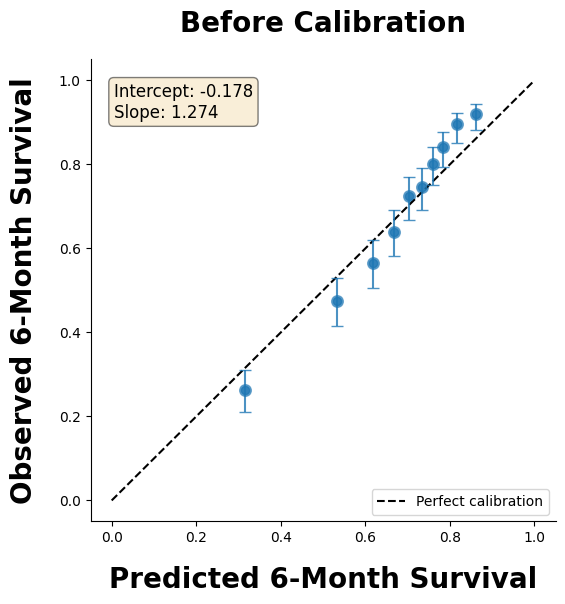

In [13]:
slope_orig, intercept_orig, _, _, _ = linregress(
    cal_df['predicted'], 
    cal_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_df['predicted'], cal_df['observed'], s = 70, alpha = 0.6)
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_df['observed'] - cal_df['obs_lo'],
    cal_df['obs_hi'] - cal_df['observed']
])

plt.errorbar(
    cal_df['predicted'],
    cal_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,    
    capsize = 4,         
    alpha = 0.8
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_orig:.3f}\nSlope: {slope_orig:.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 12, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.title('Before Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

## Isotonic Calibration Using Cross Validation 

In [14]:
# Prepare structured array for survival outcomes
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [15]:
df, brier_scores = calibrate_survival_predictions(df, y, 'psurv_180', 180)


=== Fold 1/5 ===
Brier score at 180 days (calibrated): 0.1861

=== Fold 2/5 ===
Brier score at 180 days (calibrated): 0.1742

=== Fold 3/5 ===
Brier score at 180 days (calibrated): 0.1674

=== Fold 4/5 ===
Brier score at 180 days (calibrated): 0.1789

=== Fold 5/5 ===
Brier score at 180 days (calibrated): 0.1789

=== Summary ===
psurv_180_calibrated computed: 3138

=== Brier Scores at 180 days (calibrated) ===
Mean: 0.1771 ± 0.0062


In [16]:
df_final_calibrated = df[['PatientID', 'psurv_180_calibrated']]

In [17]:
df_final_calibrated.to_csv('../outputs/cox_6m_survival_predictions_calibrated.csv', index = False)

In [18]:
cal_iso_df = calculate_calibration_curve(df, 'psurv_180_calibrated', 180)

In [19]:
cal_iso_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.001, 0.354]",0.268040,0.281694,322,0.228999,0.329604
1,"(0.354, 0.531]",0.478241,0.487724,324,0.428875,0.539785
2,"(0.531, 0.598]",0.564077,0.565493,318,0.507548,0.619288
3,"(0.598, 0.676]",0.645419,0.622532,293,0.562928,0.676418
4,"(0.676, 0.751]",0.725951,0.754682,375,0.706644,0.796008
5,"(0.751, 0.769]",0.758689,0.739587,282,0.682626,0.787934
6,"(0.769, 0.83]",0.812515,0.795416,314,0.743774,0.834578
7,"(0.83, 0.858]",0.847906,0.872305,332,0.828214,0.902490
8,"(0.858, 0.925]",0.899536,0.864002,284,0.814846,0.896717
9,"(0.925, 1.0]",0.941043,0.917935,294,0.877392,0.942339


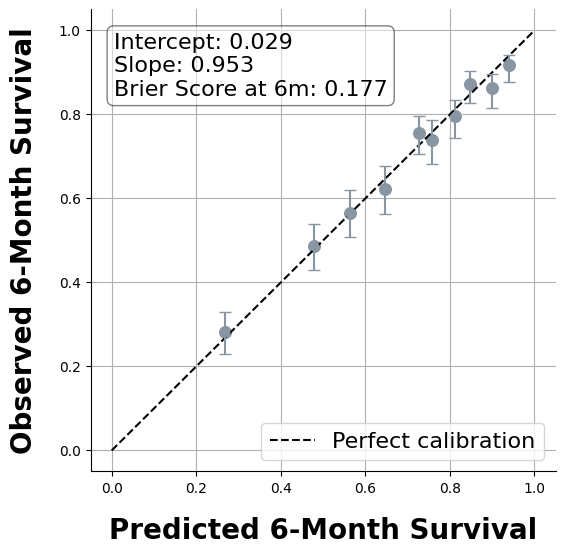

In [20]:
slope_iso, intercept_iso, _, _, _ = linregress(
    cal_iso_df['predicted'], 
    cal_iso_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_iso_df['predicted'], cal_iso_df['observed'], s = 70, color = '#8896A4')
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_iso_df['observed'] - cal_iso_df['obs_lo'],
    cal_iso_df['obs_hi'] - cal_iso_df['observed']
])

plt.errorbar(
    cal_iso_df['predicted'],
    cal_iso_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,
    color = '#8896A4',
    capsize = 4         
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_iso:.3f}\nSlope: {slope_iso:.3f}\nBrier Score at 6m: {np.mean(brier_scores):.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 16, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
#plt.title('After Isotonic Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend(fontsize=16)
plt.grid(True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()